# Experiment: Cross-Method Slight-Above Threshold Study

Objective:
- Use only the two slight-above-threshold scenarios from `mcmcis_oracle_beta_slight_above.ipynb`.
- Compare `oracle_mcmcis`, `simple_mcmcis`, and `samc`.
- Rebuild simple MCMC-IS from the current `gamma = 1/3` initialization rule.
- Use the saved best oracle-beta trial from the latest slight-above oracle-beta run.
- Use fixed local swap sizes for simple/SAMC: 2 pairs for GWAS-like scenarios and 5 pairs for Poisson/HEP-like scenarios.
- Track every method at dense checkpoints from `0.25M` through `5M` budget per run with 80 repeats.


In [1]:
from __future__ import annotations

from dataclasses import replace
import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "perm_pval").exists() and (candidate / "results").exists():
            return candidate
    raise RuntimeError("Could not locate project root containing perm_pval/ and results/.")


project_root = find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.environ.setdefault("MPLCONFIGDIR", str(project_root / ".matplotlib"))

from perm_pval.experiments.notebook_studies import (
    BetaSweepStudyConfig,
    CrossMethodStudyConfig,
    DEFAULT_MCMC_OBJECTIVE_GRID_Q_MULTIPLIERS,
    DEFAULT_MCMC_OBJECTIVE_GRID_SWAP_COUNTS,
    MCMCWorkflowConfig,
    MCMC_OBJECTIVE_GRID_REALISTIC_OBJECTIVES,
    SAMCWorkflowConfig,
    _mcmc_eval_count,
    _steps_per_chain,
    build_beta_initialization,
    build_beta_workflow,
    create_timestamped_run_dir,
    load_cross_method_saved_output,
    load_beta_sweep_saved_output,
    load_mcmc_objective_grid_saved_output,
    load_selected_scenarios,
    plot_named_method_convergence,
    plot_named_method_max_budget,
    read_json,
    run_named_mcmc_checkpoint_study,
    run_mcmc_objective_grid_study,
    save_mcmc_objective_grid_outputs,
    regenerate_beta_sweep_plots_from_saved,
    regenerate_cross_method_plots_from_saved,
    run_beta_checkpoint_study,
    run_cross_method_study,
    save_beta_sweep_outputs,
    save_cross_method_outputs,
    summarize_records,
    tune_samc_setup,
    write_json,
    write_jsonl,
    _effective_n_jobs,
    _samc_replicate_worker,
    _try_make_process_pool,
)

pd.set_option("display.max_columns", 100)
project_root

PosixPath('/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS')

## Configuration

This notebook compares SAMC against simple MCMC-IS and the saved best oracle-beta MCMC-IS trial.  
The **simple** setting uses the application-level p-value threshold as the initial `p0` guess and the current `gamma = 1/3` rule.  
The **oracle** setting is loaded from the latest oracle-beta-search notebook output. IID is not run. Each method is evaluated with `50` independent one-chain runs, so the full `5M` is the actual chain budget for every reported run.

In [2]:
FAST_MODE = False
SAVE_OUTPUTS = True

CATALOG_PATH = project_root / "results" / "exact_scenarios" / "v1" / "catalog.json"
BETA_RESULTS_ROOT = project_root / "results" / "mcmcis_beta_notebook"
OUTPUT_ROOT = project_root / "results" / "cross_method_notebook"


def latest_oracle_beta_run_dir(root: Path) -> Path:
    candidates = sorted(
        [
            path for path in Path(root).iterdir()
            if path.is_dir() and path.name.endswith("_oracle_beta_search_slight_above")
        ]
    )
    if not candidates:
        raise FileNotFoundError(
            "No slight-above oracle-beta-search run found under results/mcmcis_beta_notebook. "
            "Run mcmcis_oracle_beta_slight_above.ipynb first, or set BETA_RUN_DIR manually."
        )
    return candidates[-1]


BETA_RUN_DIR = latest_oracle_beta_run_dir(BETA_RESULTS_ROOT)

SCENARIO_KEYS_OVERRIDE = [
    "gwas_additive_score_slight_above_n100",
    "poisson_diffmeans_hep_slight_above_n200",
]
ALLOW_PARTIAL_ORACLE_BETA_REFERENCES = True

MIN_TAIL_STATES = 2
BASE_SEED = 12_345
N_METHOD_RUNS = 80 if not FAST_MODE else 3
N_JOBS = min(7, N_METHOD_RUNS, os.cpu_count() or 1)
CHAIN_BUDGET = 5_000_000 if not FAST_MODE else 1_000_000
CHECKPOINT_STEP = 250_000 if not FAST_MODE else 250_000
ESTIMATION_POINTS = tuple(range(CHECKPOINT_STEP, CHAIN_BUDGET + CHECKPOINT_STEP, CHECKPOINT_STEP))
GAMMA = 1.0 / 3.0

METHOD_ORDER = ["samc", "simple_mcmcis", "oracle_mcmcis"]
METHOD_LABELS = {
    "samc": "SAMC",
    "simple_mcmcis": "Simple-init MCMC-IS",
    "oracle_mcmcis": "Oracle MCMC-IS",
}
METHOD_COLORS = {
    "samc": "#4c8c77",
    "simple_mcmcis": "#c48a3a",
    "oracle_mcmcis": "#b04a5a",
}

cross_cfg = CrossMethodStudyConfig(
    estimation_points=ESTIMATION_POINTS,
    repeats=N_METHOD_RUNS,
    base_seed=BASE_SEED,
    iid_density_samples=0,
    min_tail_states=MIN_TAIL_STATES,
    n_jobs=N_JOBS,
)
simple_init_cfg = MCMCWorkflowConfig(
    use_true_p0_for_q_target=False,
    d_alpha=GAMMA,
    pilot_samples=200_000 if not FAST_MODE else 1_000,
    scale_method="sd",
    beta_max_init=1e6,
    tune_steps=0,
    chains=1,
    burn_in_fraction=0.20,
    thin=1,
    estimate_variance=True,
    obm_batch_size=None,
    chain_n_jobs=1,
    tilt_mode="smooth_hinge",
    proposal_size=1,
    local_scan_enabled=False,
)
mcmc_template_cfg = MCMCWorkflowConfig(
    pilot_samples=0,
    tune_steps=0,
    chains=1,
    burn_in_fraction=0.20,
    thin=1,
    estimate_variance=True,
    obm_batch_size=None,
    chain_n_jobs=1,
    tilt_mode="smooth_hinge",
    proposal_size=1,
    local_scan_enabled=False,
)
samc_base_cfg = SAMCWorkflowConfig(
    n_bins=100,
    t0=1_000.0,
    trace_every=200 if not FAST_MODE else 50,
    lambda_min_pilot=10_000 if not FAST_MODE else 1_000,
    proposal_size=1,
)

NOTEBOOK_CONFIG = {
    "FAST_MODE": FAST_MODE,
    "SAVE_OUTPUTS": SAVE_OUTPUTS,
    "BETA_RUN_DIR": str(BETA_RUN_DIR),
    "SCENARIO_KEYS_OVERRIDE": SCENARIO_KEYS_OVERRIDE,
    "ALLOW_PARTIAL_ORACLE_BETA_REFERENCES": ALLOW_PARTIAL_ORACLE_BETA_REFERENCES,
    "MIN_TAIL_STATES": MIN_TAIL_STATES,
    "BASE_SEED": BASE_SEED,
    "N_METHOD_RUNS": N_METHOD_RUNS,
    "N_JOBS": N_JOBS,
    "CHAIN_BUDGET": CHAIN_BUDGET,
    "CHECKPOINT_STEP": CHECKPOINT_STEP,
    "N_CHECKPOINTS": len(ESTIMATION_POINTS),
    "METHOD_ORDER": METHOD_ORDER,
    "RUNS_IID": False,
    "GAMMA": float(GAMMA),
    "MCMC_INIT_COMPARISON": "simple_current_rule_vs_oracle_beta_best_trial",
    "SIMPLE_INIT_P0_MODE": "known_significance_threshold_else_default_guess",
    "ORACLE_INIT_P0_MODE": "saved_oracle_beta_best_trial",
    "SIMPLE_AND_SAMC_PROPOSAL_SIZE_RULE": "gwas=2 swap pairs; hep/poisson=5 swap pairs",
    "USES_SAVED_ORACLE_ONLY": True,
    "SIMPLE_INIT_GAMMA": float(simple_init_cfg.d_alpha),
    "ORACLE_INIT_GAMMA": float(simple_init_cfg.d_alpha),
    "SIMPLE_INIT_PILOT_SAMPLES": int(simple_init_cfg.pilot_samples),
    "COUNTS_INCLUDE_PILOT_BUDGET": False,
    "PLOT_X_SCALE": "linear",
    "CONVERGENCE_FIGURES": ["mean_estimate", "median_estimate"],
}

print(json.dumps(NOTEBOOK_CONFIG, indent=2))

{
  "FAST_MODE": false,
  "SAVE_OUTPUTS": true,
  "BETA_RUN_DIR": "/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/mcmcis_beta_notebook/20260616_200528_oracle_beta_search_slight_above",
  "SCENARIO_KEYS_OVERRIDE": [
    "gwas_additive_score_slight_above_n100",
    "poisson_diffmeans_hep_slight_above_n200"
  ],
  "ALLOW_PARTIAL_ORACLE_BETA_REFERENCES": true,
  "MIN_TAIL_STATES": 2,
  "BASE_SEED": 12345,
  "N_METHOD_RUNS": 80,
  "N_JOBS": 7,
  "CHAIN_BUDGET": 5000000,
  "CHECKPOINT_STEP": 250000,
  "N_CHECKPOINTS": 20,
  "METHOD_ORDER": [
    "samc",
    "simple_mcmcis",
    "oracle_mcmcis"
  ],
  "RUNS_IID": false,
  "GAMMA": 0.3333333333333333,
  "MCMC_INIT_COMPARISON": "simple_current_rule_vs_oracle_beta_best_trial",
  "SIMPLE_INIT_P0_MODE": "known_significance_threshold_else_default_guess",
  "ORACLE_INIT_P0_MODE": "saved_oracle_beta_best_trial",
  "SIMPLE_AND_SAMC_PROPOSAL_SIZE_RULE": "gwas=2 swap pairs; hep/poisson=5 swap pairs",
  "USES_SAVED_ORACLE_ONLY": true,

## Notebook Helpers

In [3]:
def proposal_size_for_scenario(scenario) -> int:
    setting_key = str(scenario.extra.get("application_setting_key", ""))
    if setting_key == "gwas_threshold_suite":
        return 2
    if setting_key == "hep_threshold_suite":
        return 5
    return max(1, int(round(0.05 * min(scenario.problem.n_treated, scenario.problem.n_control))))


def samc_cfg_for_scenario(scenario):
    return replace(
        samc_base_cfg,
        proposal_size=int(proposal_size_for_scenario(scenario)),
    )


def build_p0_reference(scenario) -> dict:
    known_threshold = scenario.extra.get("known_significance_threshold")
    if known_threshold is None:
        simple_p0 = float(simple_init_cfg.p0_guess)
        simple_source = "default_guess"
    else:
        simple_p0 = float(known_threshold)
        simple_source = "known_significance_threshold"
    return {
        "scenario": scenario.key,
        "simple_reference_p0": simple_p0,
        "simple_reference_p0_source": simple_source,
        "oracle_reference_p0": float(scenario.exact_p),
        "known_significance_threshold": known_threshold,
        "application_setting_key": scenario.extra.get("application_setting_key"),
        "application_setting_label": scenario.extra.get("application_setting_label"),
    }


def build_simple_reference(scenario, p0_reference: dict, *, seed: int) -> dict:
    p0_value = float(p0_reference["simple_reference_p0"])
    init_payload = build_beta_initialization(
        scenario.problem,
        scenario.exact_p,
        simple_init_cfg,
        seed=int(seed),
        p0_reference=p0_value,
    )
    proposal_size = int(proposal_size_for_scenario(scenario))
    return {
        "scenario": scenario.key,
        "simple_gamma": float(simple_init_cfg.d_alpha),
        "simple_reference_p0": p0_value,
        "simple_reference_p0_source": p0_reference["simple_reference_p0_source"],
        "simple_q_target": float(init_payload["q_target"]),
        "simple_beta": float(init_payload["beta0_laplace"]),
        "simple_sigma_t": float(init_payload["sigma_t"]),
        "simple_proposal_size": proposal_size,
        "pilot_eval_total": int(init_payload["pilot_eval_total"]),
        "pilot_wall_time_sec": float(init_payload["pilot_wall_time_sec"]),
    }


def load_oracle_beta_reference(beta_run_dir: Path, scenario_key: str) -> dict:
    scenario_dir = Path(beta_run_dir) / scenario_key
    best_path = scenario_dir / "best_config.json"
    reference_status = "final"
    if not best_path.exists():
        best_path = scenario_dir / "best_config.partial.json"
        reference_status = "partial"
    if not best_path.exists():
        raise FileNotFoundError(f"No oracle beta best config found for {scenario_key}: {scenario_dir}")
    if reference_status == "partial" and not ALLOW_PARTIAL_ORACLE_BETA_REFERENCES:
        raise FileNotFoundError(
            f"Only a partial oracle beta config exists for {scenario_key}. "
            "Set ALLOW_PARTIAL_ORACLE_BETA_REFERENCES=True to use it."
        )
    best_config = read_json(best_path)
    status_path = scenario_dir / "hpo_status.json"
    status = read_json(status_path) if status_path.exists() else {}
    oracle_summary_path = scenario_dir / "oracle_best_trial.json"
    oracle_summary = read_json(oracle_summary_path) if oracle_summary_path.exists() else None
    return {
        "scenario": scenario_key,
        "oracle_beta_run_dir": str(scenario_dir),
        "oracle_reference_status": reference_status,
        "oracle_reference_path": str(best_path),
        "oracle_gamma": float(best_config["best_gamma"]),
        "oracle_reference_p0": float(best_config["reference_p0"]),
        "oracle_reference_p0_source": "exact_p",
        "oracle_q_target": float(best_config["best_q_target"]),
        "oracle_beta": float(best_config["best_beta"]),
        "oracle_sigma_t": float(best_config["sigma_t"]),
        "oracle_proposal_size": int(best_config["best_proposal_size"]),
        "oracle_best_trial_number": int(best_config["best_trial_number"]),
        "oracle_objective_value": float(best_config["best_objective_value"]),
        "oracle_completed_trials": int(best_config.get("n_trials", best_config.get("completed_trials", status.get("completed_trials", 0)))),
        "oracle_target_trials": status.get("target_trials"),
        "simple_reference_p0": float(best_config.get("simple_reference_p0", best_config["reference_p0"])),
        "canonical_threshold_p0": best_config.get("canonical_threshold_p0"),
        "oracle_summary": oracle_summary,
    }


def build_mcmc_config_specs(simple_reference: dict, oracle_reference: dict | None = None) -> list[dict]:
    specs = [
        {
            "label": "simple_mcmcis",
            "config_id": "simple_mcmcis",
            "beta": float(simple_reference["simple_beta"]),
            "proposal_size": int(simple_reference["simple_proposal_size"]),
            "source": "current_simple_rule",
        },
    ]
    if oracle_reference is not None:
        specs.append(
            {
                "label": "oracle_mcmcis",
                "config_id": f"oracle_beta_trial_{int(oracle_reference['oracle_best_trial_number']):02d}",
                "beta": float(oracle_reference["oracle_beta"]),
                "proposal_size": int(oracle_reference["oracle_proposal_size"]),
                "source": f"oracle_beta_search_{oracle_reference['oracle_reference_status']}",
            }
        )
    return specs


def run_parallel_worker_jobs(worker_fn, jobs: list[dict], *, n_jobs: int) -> list[dict]:
    n_workers = _effective_n_jobs(int(n_jobs), len(jobs))
    executor = _try_make_process_pool(n_workers) if n_workers > 1 else None
    rows: list[dict] = []
    if executor is None:
        for job in jobs:
            rows.extend(worker_fn(**job))
        return rows

    with executor:
        futures = [executor.submit(worker_fn, **job) for job in jobs]
        for future in futures:
            rows.extend(future.result())
    return rows


def run_samc_baseline(scenario, *, base_seed: int, samc_cfg) -> tuple[list[dict], dict]:
    checkpoints = tuple(int(v) for v in cross_cfg.estimation_points)
    samc_setup = tune_samc_setup(
        scenario.problem,
        samc_cfg,
        seed=int(base_seed + 50_000),
    )
    samc_jobs = [
        {
            "scenario_key": scenario.key,
            "scenario_display": scenario.description,
            "problem": scenario.problem,
            "exact_p": scenario.exact_p,
            "checkpoints": checkpoints,
            "samc_setup": samc_setup,
            "samc_cfg": samc_cfg,
            "rep": int(rep),
            "rep_seed": int(base_seed + 100_000 + 1_000 * rep),
        }
        for rep in range(int(cross_cfg.repeats))
    ]
    samc_rows = run_parallel_worker_jobs(_samc_replicate_worker, samc_jobs, n_jobs=int(cross_cfg.n_jobs))
    for row in samc_rows:
        row["label"] = "samc"

    return samc_rows, samc_setup


def save_oracle_cross_method_outputs(
    scenario,
    study: dict,
    *,
    output_dir: Path,
    p0_reference: dict,
    samc_cfg,
) -> None:
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    known_threshold = p0_reference.get("known_significance_threshold")
    method_order = list(study.get("method_order", METHOD_ORDER))

    plot_named_method_max_budget(
        study["records"],
        scenario_name=study["scenario_display"],
        scenario_key=study["scenario"],
        exact_p=float(study["exact_p"]),
        max_budget=max(int(v) for v in study["estimation_points"]),
        method_order=method_order,
        method_labels=METHOD_LABELS,
        method_colors=METHOD_COLORS,
        n_control=int(scenario.problem.n_control),
        n_treated=int(scenario.problem.n_treated),
        known_significance_threshold=(
            float(known_threshold)
            if known_threshold is not None
            else None
        ),
        save_path=output_dir / "cross_method_max_budget.png",
    )
    plot_named_method_convergence(
        study["summary"],
        scenario_name=study["scenario_display"],
        scenario_key=study["scenario"],
        exact_p=float(study["exact_p"]),
        method_order=method_order,
        method_labels=METHOD_LABELS,
        method_colors=METHOD_COLORS,
        n_control=int(scenario.problem.n_control),
        n_treated=int(scenario.problem.n_treated),
        known_significance_threshold=(
            float(known_threshold)
            if known_threshold is not None
            else None
        ),
        x_label="Budget per run",
        save_path=output_dir / "cross_method_convergence.png",
    )
    plot_named_method_convergence(
        study["summary"],
        scenario_name=study["scenario_display"],
        scenario_key=study["scenario"],
        exact_p=float(study["exact_p"]),
        method_order=method_order,
        method_labels=METHOD_LABELS,
        method_colors=METHOD_COLORS,
        n_control=int(scenario.problem.n_control),
        n_treated=int(scenario.problem.n_treated),
        known_significance_threshold=(
            float(known_threshold)
            if known_threshold is not None
            else None
        ),
        x_label="Budget per run",
        estimate_field="median_estimate",
        estimate_title="Median estimate",
        estimate_ylabel=r"median $\hat{p}$",
        save_path=output_dir / "cross_method_convergence_median.png",
    )
    write_jsonl(output_dir / "run_records.jsonl", study["records"])
    write_json(output_dir / "summary.json", study["summary"])
    write_json(
        output_dir / "metadata.json",
        {
            "scenario": study["scenario"],
            "scenario_display": study["scenario_display"],
            "scenario_portfolio": study["scenario_portfolio"],
            "exact_p": study["exact_p"],
            "exact_method": study["exact_method"],
            "exact_tail_hits": study["exact_tail_hits"],
            "exact_n_perm": study["exact_n_perm"],
            "n_treated": int(scenario.problem.n_treated),
            "n_control": int(scenario.problem.n_control),
            "n_total": int(scenario.problem.n),
            "estimation_points": study["estimation_points"],
            "method_order": method_order,
            "method_labels": METHOD_LABELS,
            "method_colors": METHOD_COLORS,
            "x_label": "Budget per run",
            "x_scale": "linear",
            "convergence_plot_fields": {
                "mean": "mean_estimate",
                "median": "median_estimate",
            },
            "cross_config": cross_cfg,
            "simple_init_config": simple_init_cfg,
            "mcmc_template_config": mcmc_template_cfg,
            "samc_config": samc_cfg,
            "simple_reference": study["simple_reference"],
            "oracle_reference": study["oracle_reference"],
            "p0_reference": p0_reference,
            "samc_setup": study["samc_setup"],
            "notebook_config": NOTEBOOK_CONFIG,
        },
    )


def regenerate_oracle_cross_method_plots(
    scenario_dir: Path,
    *,
    save_dir: Path | None = None,
) -> dict[str, Path]:
    saved = load_cross_method_saved_output(scenario_dir)
    metadata = saved["metadata"]
    p0_reference = dict(metadata.get("p0_reference", metadata.get("beta_reference", {})))
    save_dir = Path(save_dir) if save_dir is not None else Path(scenario_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    max_budget = max(int(v) for v in metadata["estimation_points"])
    known_threshold = p0_reference.get("known_significance_threshold")
    out = {
        "cross_method_max_budget": save_dir / "cross_method_max_budget.png",
        "cross_method_convergence": save_dir / "cross_method_convergence.png",
        "cross_method_convergence_median": save_dir / "cross_method_convergence_median.png",
    }
    plot_named_method_max_budget(
        saved["records"],
        scenario_name=str(metadata["scenario_display"]),
        scenario_key=str(metadata["scenario"]),
        exact_p=float(metadata["exact_p"]),
        max_budget=max_budget,
        method_order=list(metadata.get("method_order", METHOD_ORDER)),
        method_labels=dict(METHOD_LABELS),
        method_colors=dict(METHOD_COLORS),
        n_control=int(metadata["n_control"]),
        n_treated=int(metadata["n_treated"]),
        known_significance_threshold=(
            float(known_threshold)
            if known_threshold is not None
            else None
        ),
        save_path=out["cross_method_max_budget"],
    )
    plot_named_method_convergence(
        saved["summary"],
        scenario_name=str(metadata["scenario_display"]),
        scenario_key=str(metadata["scenario"]),
        exact_p=float(metadata["exact_p"]),
        method_order=list(metadata.get("method_order", METHOD_ORDER)),
        method_labels=dict(METHOD_LABELS),
        method_colors=dict(METHOD_COLORS),
        n_control=int(metadata["n_control"]),
        n_treated=int(metadata["n_treated"]),
        known_significance_threshold=(
            float(known_threshold)
            if known_threshold is not None
            else None
        ),
        x_label=str(metadata.get("x_label", "Budget per run")),
        save_path=out["cross_method_convergence"],
    )
    plot_named_method_convergence(
        saved["summary"],
        scenario_name=str(metadata["scenario_display"]),
        scenario_key=str(metadata["scenario"]),
        exact_p=float(metadata["exact_p"]),
        method_order=list(metadata.get("method_order", METHOD_ORDER)),
        method_labels=dict(METHOD_LABELS),
        method_colors=dict(METHOD_COLORS),
        n_control=int(metadata["n_control"]),
        n_treated=int(metadata["n_treated"]),
        known_significance_threshold=(
            float(known_threshold)
            if known_threshold is not None
            else None
        ),
        x_label=str(metadata.get("x_label", "Budget per run")),
        estimate_field="median_estimate",
        estimate_title="Median estimate",
        estimate_ylabel=r"median $\hat{p}$",
        save_path=out["cross_method_convergence_median"],
    )
    return out

## Load Scenarios and Oracle Beta References

In [4]:
scenarios = load_selected_scenarios(
    catalog_path=CATALOG_PATH,
    scenario_keys=SCENARIO_KEYS_OVERRIDE,
    portfolio_group=None,
    min_tail_states=MIN_TAIL_STATES,
)

p0_references = {
    scenario.key: build_p0_reference(scenario)
    for scenario in scenarios
}
simple_references = {
    scenario.key: build_simple_reference(
        scenario,
        p0_references[scenario.key],
        seed=int(BASE_SEED + 50_000 * (scenario_idx + 1)),
    )
    for scenario_idx, scenario in enumerate(scenarios)
}
oracle_references = {
    scenario.key: load_oracle_beta_reference(BETA_RUN_DIR, scenario.key)
    for scenario in scenarios
}
run_dir = create_timestamped_run_dir(OUTPUT_ROOT, "cross_method_oracle_beta_slight_above_compare") if SAVE_OUTPUTS else None

pd.DataFrame(
    [
        {
            "scenario": scenario.key,
            "exact_p": scenario.exact_p,
            "known_threshold": scenario.extra.get("known_significance_threshold"),
            "p_over_threshold": (
                float(scenario.exact_p) / float(scenario.extra["known_significance_threshold"])
                if scenario.extra.get("known_significance_threshold") is not None
                else None
            ),
            "threshold_band": scenario.extra.get("threshold_band"),
            "tail_hits": scenario.exact_tail_hits,
            "n_perm": scenario.exact_n_perm,
            "family": scenario.portfolio.get("family"),
            "rarity_band": scenario.portfolio.get("rarity_band"),
            "simple_beta": simple_references[scenario.key]["simple_beta"],
            "simple_prop": simple_references[scenario.key]["simple_proposal_size"],
            "simple_gamma": simple_references[scenario.key]["simple_gamma"],
            "simple_p0": simple_references[scenario.key]["simple_reference_p0"],
            "simple_q_target": simple_references[scenario.key]["simple_q_target"],
            "oracle_status": oracle_references[scenario.key]["oracle_reference_status"],
            "oracle_trial": oracle_references[scenario.key]["oracle_best_trial_number"],
            "oracle_beta": oracle_references[scenario.key]["oracle_beta"],
            "oracle_prop": oracle_references[scenario.key]["oracle_proposal_size"],
            "oracle_gamma": oracle_references[scenario.key]["oracle_gamma"],
            "oracle_p0": oracle_references[scenario.key]["oracle_reference_p0"],
            "oracle_q_target": oracle_references[scenario.key]["oracle_q_target"],
        }
        for scenario in scenarios
    ]
)

,scenario,exact_p,known_threshold,p_over_threshold,threshold_band,tail_hits,n_perm,family,rarity_band,simple_beta,simple_prop,simple_gamma,simple_p0,simple_q_target,oracle_status,oracle_trial,oracle_beta,oracle_prop,oracle_gamma,oracle_p0,oracle_q_target
0,gwas_additive_score_slight_above_n100,5.795410e-08,5.000000e-08,1.159082,slightly_above,5847067352508480691528,100891344545564193334812497256,gwas_additive_score,extreme,3.356445,2,0.333333,5.000000e-08,0.003684,final,9,2.955078,3,0.375,5.795410e-08,0.001933
1,poisson_diffmeans_hep_slight_above_n200,3.508746e-07,3.000000e-07,1.169582,slightly_above,3177117007379982237913910754995818354531866351...,9054851465610328116540417707748416387450458967...,poisson_count,extreme,2.861328,5,0.333333,3.000000e-07,0.006694,partial,12,2.149414,8,0.450,3.508746e-07,0.001245


## Run Cross-Method Study

For each scenario:
- rebuild **simple-init** MCMC-IS from the current `gamma = 1/3` rule,
- load **oracle** MCMC-IS from the saved best oracle-beta trial,
- run `50` independent one-chain replicates for each method,
- save the article-facing max-budget plot plus both mean- and median-based convergence plots.

In [5]:
cross_results = {}

for scenario_idx, scenario in enumerate(scenarios):
    p0_reference = p0_references[scenario.key]
    simple_reference = simple_references[scenario.key]
    oracle_reference = oracle_references[scenario.key]
    scenario_method_order = list(METHOD_ORDER)
    scenario_seed = int(BASE_SEED + 1_000_000 * (scenario_idx + 1))
    scenario_samc_cfg = samc_cfg_for_scenario(scenario)
    mcmc_specs = build_mcmc_config_specs(simple_reference, oracle_reference)
    simple_specs = mcmc_specs[:1]
    oracle_specs = mcmc_specs[1:]

    print(f"Running {scenario.key} | exact p={scenario.exact_p:.3e}")
    print(json.dumps({
        "scenario": scenario.key,
        "n_method_runs": int(cross_cfg.repeats),
        "n_jobs": int(cross_cfg.n_jobs),
        "chain_budget": CHAIN_BUDGET,
        "first_checkpoints": [int(v) for v in ESTIMATION_POINTS[:4]],
        "last_checkpoint": int(ESTIMATION_POINTS[-1]),
        "simple_beta": simple_reference["simple_beta"],
        "simple_proposal_size": simple_reference["simple_proposal_size"],
        "simple_gamma": simple_reference["simple_gamma"],
        "simple_reference_p0": simple_reference["simple_reference_p0"],
        "simple_q_target": simple_reference["simple_q_target"],
        "simple_sigma_t": simple_reference["simple_sigma_t"],
        "simple_pilot_eval_total": simple_reference["pilot_eval_total"],
        "oracle_status": oracle_reference["oracle_reference_status"],
        "oracle_trial": oracle_reference["oracle_best_trial_number"],
        "oracle_beta": oracle_reference["oracle_beta"],
        "oracle_proposal_size": oracle_reference["oracle_proposal_size"],
        "oracle_gamma": oracle_reference["oracle_gamma"],
        "oracle_reference_p0": oracle_reference["oracle_reference_p0"],
        "oracle_q_target": oracle_reference["oracle_q_target"],
        "oracle_sigma_t": oracle_reference["oracle_sigma_t"],
        "oracle_completed_trials": oracle_reference["oracle_completed_trials"],
        "oracle_target_trials": oracle_reference["oracle_target_trials"],
        "samc_proposal_size": scenario_samc_cfg.proposal_size,
    }, indent=2))

    simple_study = run_named_mcmc_checkpoint_study(
        scenario.problem,
        scenario.exact_p,
        config_specs=simple_specs,
        sigma_t=float(simple_reference["simple_sigma_t"]),
        estimation_points=tuple(int(v) for v in cross_cfg.estimation_points),
        repeats=int(cross_cfg.repeats),
        base_seed=scenario_seed,
        template_cfg=mcmc_template_cfg,
        n_jobs=int(cross_cfg.n_jobs),
    )
    oracle_study = run_named_mcmc_checkpoint_study(
        scenario.problem,
        scenario.exact_p,
        config_specs=oracle_specs,
        sigma_t=float(oracle_reference["oracle_sigma_t"]),
        estimation_points=tuple(int(v) for v in cross_cfg.estimation_points),
        repeats=int(cross_cfg.repeats),
        base_seed=scenario_seed + 200_000,
        template_cfg=mcmc_template_cfg,
        n_jobs=int(cross_cfg.n_jobs),
    )
    samc_rows, samc_setup = run_samc_baseline(
        scenario,
        base_seed=scenario_seed + 400_000,
        samc_cfg=scenario_samc_cfg,
    )

    records = list(simple_study["records"]) + list(oracle_study["records"]) + list(samc_rows)
    records = sorted(
        records,
        key=lambda row: (
            str(row.get("label", row.get("method", ""))),
            int(row["replicate"]),
            int(row["checkpoint"]),
        ),
    )
    summary = summarize_records(records, group_fields=("checkpoint", "label"))

    study = {
        "scenario": scenario.key,
        "scenario_display": scenario.description,
        "scenario_portfolio": dict(scenario.portfolio),
        "exact_p": float(scenario.exact_p),
        "exact_method": scenario.exact_method,
        "exact_tail_hits": int(scenario.exact_tail_hits),
        "exact_n_perm": int(scenario.exact_n_perm),
        "estimation_points": [int(v) for v in cross_cfg.estimation_points],
        "records": records,
        "summary": summary,
        "method_order": scenario_method_order,
        "oracle_skipped": False,
        "p0_reference": p0_reference,
        "simple_reference": simple_reference,
        "oracle_reference": oracle_reference,
        "samc_setup": {
            "lambda_min": float(samc_setup["lambda_min"]),
            "bin_edges": samc_setup["bin_edges"],
        },
    }
    cross_results[scenario.key] = study

    if SAVE_OUTPUTS and run_dir is not None:
        save_oracle_cross_method_outputs(
            scenario,
            study,
            output_dir=run_dir / scenario.key,
            p0_reference=p0_reference,
            samc_cfg=scenario_samc_cfg,
        )

    summary_df = pd.DataFrame(summary).sort_values(["checkpoint", "label"])
    display(
        summary_df[
            [
                "checkpoint",
                "label",
                "mean_estimate",
                "median_estimate",
                "rmse",
                "mean_abs_log10_error",
                "mean_eval_excl_tuning",
                "mean_q_tilt_tail_share",
                "mean_ess",
                "mean_acceptance_rate",
                "mean_zero_rate",
                "mean_samc_max_rel_freq_error",
            ]
        ]
    )

family_rows = []
for scenario in scenarios:
    meta = scenario.portfolio
    for row in cross_results[scenario.key]["summary"]:
        family_rows.append(
            {
                "scenario": scenario.key,
                "family": meta.get("family"),
                "rarity_band": meta.get("rarity_band"),
                "difficulty": meta.get("expected_difficulty"),
                **row,
            }
        )

family_df = pd.DataFrame(family_rows)
display(
    family_df.groupby(["family", "rarity_band", "label", "checkpoint"], as_index=False)
    .agg(
        mean_rmse=("rmse", "mean"),
        mean_estimate=("mean_estimate", "mean"),
        mean_abs_log10_error=("mean_abs_log10_error", "mean"),
        mean_q_tilt_tail_share=("mean_q_tilt_tail_share", "mean"),
        mean_ess=("mean_ess", "mean"),
        mean_acceptance_rate=("mean_acceptance_rate", "mean"),
    )
    .sort_values(["family", "rarity_band", "checkpoint", "label"])
)

Running gwas_additive_score_slight_above_n100 | exact p=5.795e-08
{
  "scenario": "gwas_additive_score_slight_above_n100",
  "n_method_runs": 80,
  "n_jobs": 7,
  "chain_budget": 5000000,
  "first_checkpoints": [
    250000,
    500000,
    750000,
    1000000
  ],
  "last_checkpoint": 5000000,
  "simple_beta": 3.3564453125,
  "simple_proposal_size": 2,
  "simple_gamma": 0.3333333333333333,
  "simple_reference_p0": 5e-08,
  "simple_q_target": 0.0036840314986403876,
  "simple_sigma_t": 2.665182043008809,
  "simple_pilot_eval_total": 200000,
  "oracle_status": "final",
  "oracle_trial": 9,
  "oracle_beta": 2.955078125,
  "oracle_proposal_size": 3,
  "oracle_gamma": 0.375,
  "oracle_reference_p0": 5.795410279092721e-08,
  "oracle_q_target": 0.0019326649477126642,
  "oracle_sigma_t": 2.6651175604901662,
  "oracle_completed_trials": 15,
  "oracle_target_trials": 15,
  "samc_proposal_size": 2
}


,checkpoint,label,mean_estimate,median_estimate,rmse,mean_abs_log10_error,mean_eval_excl_tuning,mean_q_tilt_tail_share,mean_ess,mean_acceptance_rate,mean_zero_rate,mean_samc_max_rel_freq_error
0,250000,oracle_mcmcis,6.111904e-08,6.004888e-08,1.652584e-08,0.091297,250001.0,0.001802,508.174275,0.536210,NaN,NaN
1,250000,samc,5.941659e-08,5.166443e-08,4.240548e-08,0.219154,250001.0,NaN,NaN,0.716647,NaN,2.235931
2,250000,simple_mcmcis,6.638646e-08,6.450659e-08,2.193147e-08,0.126359,250001.0,0.004254,335.850876,0.597250,NaN,NaN
3,500000,oracle_mcmcis,5.946411e-08,5.889282e-08,1.168920e-08,0.069766,500001.0,0.001802,775.131262,0.536209,NaN,NaN
4,500000,samc,4.950403e-08,4.831354e-08,2.290591e-08,0.177858,500001.0,NaN,NaN,0.718823,NaN,1.480547
5,500000,simple_mcmcis,6.386556e-08,6.514840e-08,1.697719e-08,0.092971,500001.0,0.004236,498.140734,0.597442,NaN,NaN
6,750000,oracle_mcmcis,5.896292e-08,5.929705e-08,9.613313e-09,0.057684,750001.0,0.001771,1059.300206,0.536215,NaN,NaN
7,750000,samc,5.588648e-08,5.484758e-08,1.970877e-08,0.132033,750001.0,NaN,NaN,0.719535,NaN,1.105735
8,750000,simple_mcmcis,6.256788e-08,6.301216e-08,1.222409e-08,0.071971,750001.0,0.004189,592.029504,0.597402,NaN,NaN
9,1000000,oracle_mcmcis,5.822494e-08,5.858974e-08,8.553408e-09,0.050005,1000001.0,0.001747,1258.774743,0.536236,NaN,NaN


Running poisson_diffmeans_hep_slight_above_n200 | exact p=3.509e-07
{
  "scenario": "poisson_diffmeans_hep_slight_above_n200",
  "n_method_runs": 80,
  "n_jobs": 7,
  "chain_budget": 5000000,
  "first_checkpoints": [
    250000,
    500000,
    750000,
    1000000
  ],
  "last_checkpoint": 5000000,
  "simple_beta": 2.861328125,
  "simple_proposal_size": 5,
  "simple_gamma": 0.3333333333333333,
  "simple_reference_p0": 3e-07,
  "simple_q_target": 0.006694329500821697,
  "simple_sigma_t": 0.21952314715047858,
  "simple_pilot_eval_total": 200000,
  "oracle_status": "partial",
  "oracle_trial": 12,
  "oracle_beta": 2.1494140625,
  "oracle_proposal_size": 8,
  "oracle_gamma": 0.45,
  "oracle_reference_p0": 3.5087455817982693e-07,
  "oracle_q_target": 0.0012454271971786273,
  "oracle_sigma_t": 0.21997981736820815,
  "oracle_completed_trials": 14,
  "oracle_target_trials": 15,
  "samc_proposal_size": 5
}


,checkpoint,label,mean_estimate,median_estimate,rmse,mean_abs_log10_error,mean_eval_excl_tuning,mean_q_tilt_tail_share,mean_ess,mean_acceptance_rate,mean_zero_rate,mean_samc_max_rel_freq_error
0,250000,oracle_mcmcis,3.505809e-07,3.438274e-07,8.337687e-08,0.087522,250001.0,0.001251,3317.290702,0.548867,NaN,NaN
1,250000,samc,3.181363e-07,3.155635e-07,7.662005e-08,0.087162,250001.0,NaN,NaN,0.640905,NaN,5.590000
2,250000,simple_mcmcis,3.685812e-07,3.671778e-07,7.051918e-08,0.064588,250001.0,0.007256,609.442638,0.532619,NaN,NaN
3,500000,oracle_mcmcis,3.537761e-07,3.561260e-07,5.753673e-08,0.057478,500001.0,0.001263,5921.915123,0.548851,NaN,NaN
4,500000,samc,3.514119e-07,3.436741e-07,7.388029e-08,0.070994,500001.0,NaN,NaN,0.644065,NaN,4.100937
5,500000,simple_mcmcis,3.719111e-07,3.742591e-07,5.955492e-08,0.056277,500001.0,0.007309,993.513623,0.532527,NaN,NaN
6,750000,oracle_mcmcis,3.495303e-07,3.484158e-07,4.304082e-08,0.040991,750001.0,0.001249,8049.672881,0.548766,NaN,NaN
7,750000,samc,3.504630e-07,3.458755e-07,4.880235e-08,0.046999,750001.0,NaN,NaN,0.645260,NaN,3.067083
8,750000,simple_mcmcis,3.659643e-07,3.623309e-07,4.462882e-08,0.041233,750001.0,0.007265,1280.295303,0.532547,NaN,NaN
9,1000000,oracle_mcmcis,3.498397e-07,3.470341e-07,3.253948e-08,0.031444,1000001.0,0.001251,10598.675477,0.548773,NaN,NaN


,family,rarity_band,label,checkpoint,mean_rmse,mean_estimate,mean_abs_log10_error,mean_q_tilt_tail_share,mean_ess,mean_acceptance_rate
0,gwas_additive_score,extreme,oracle_mcmcis,250000,1.652584e-08,6.111904e-08,0.091297,0.001802,508.174275,0.536210
20,gwas_additive_score,extreme,samc,250000,4.240548e-08,5.941659e-08,0.219154,NaN,NaN,0.716647
40,gwas_additive_score,extreme,simple_mcmcis,250000,2.193147e-08,6.638646e-08,0.126359,0.004254,335.850876,0.597250
1,gwas_additive_score,extreme,oracle_mcmcis,500000,1.168920e-08,5.946411e-08,0.069766,0.001802,775.131262,0.536209
21,gwas_additive_score,extreme,samc,500000,2.290591e-08,4.950403e-08,0.177858,NaN,NaN,0.718823
...,...,...,...,...,...,...,...,...,...,...
98,poisson_count,extreme,samc,4750000,2.039697e-08,3.478262e-07,0.020670,NaN,NaN,0.647629
118,poisson_count,extreme,simple_mcmcis,4750000,2.102287e-08,3.543955e-07,0.020902,0.007236,4869.945468,0.532622
79,poisson_count,extreme,oracle_mcmcis,5000000,1.503020e-08,3.501526e-07,0.014726,0.001246,49536.272703,0.548750
99,poisson_count,extreme,samc,5000000,1.857071e-08,3.468416e-07,0.018816,NaN,NaN,0.647684


## Review Saved Figures

Saved outputs under: /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_notebook/20260617_204956_cross_method_oracle_beta_slight_above_compare

gwas_additive_score_slight_above_n100


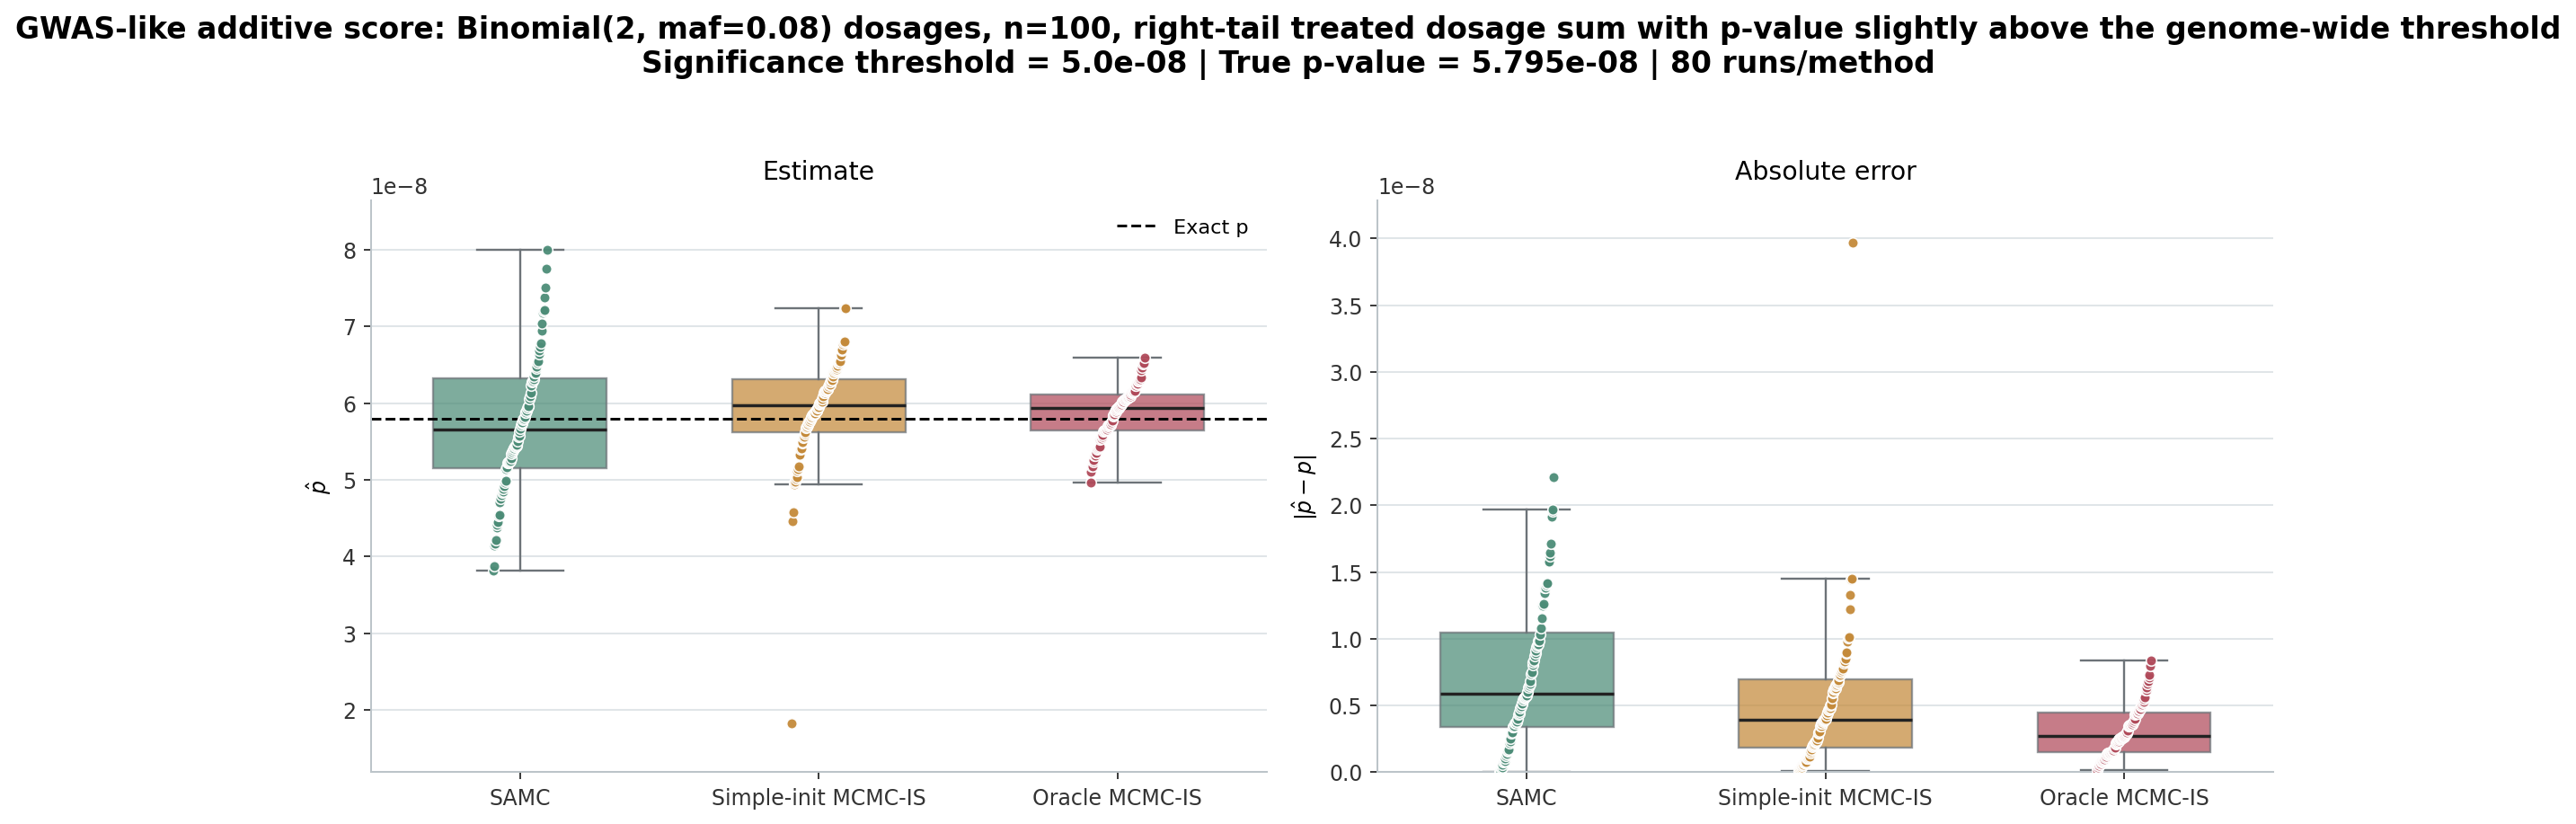

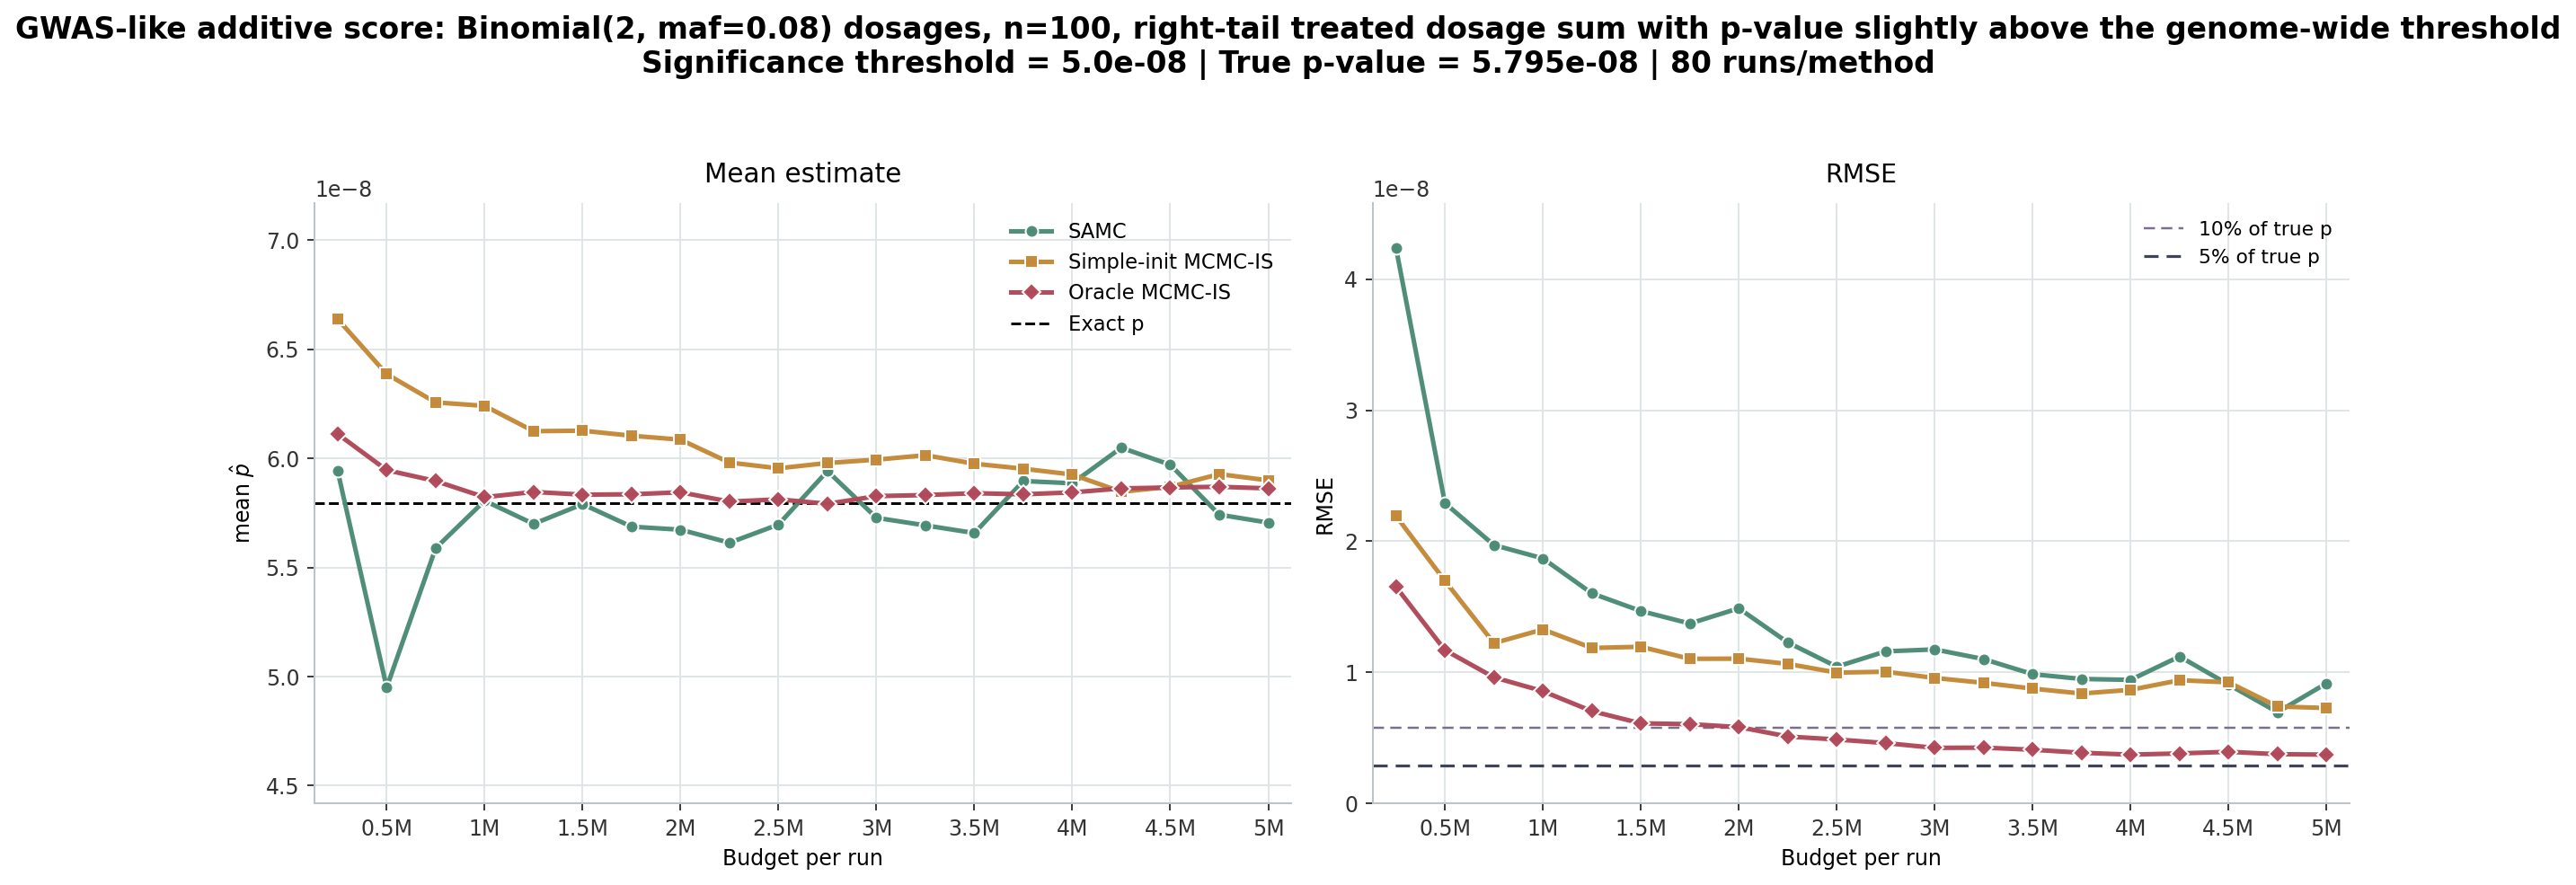

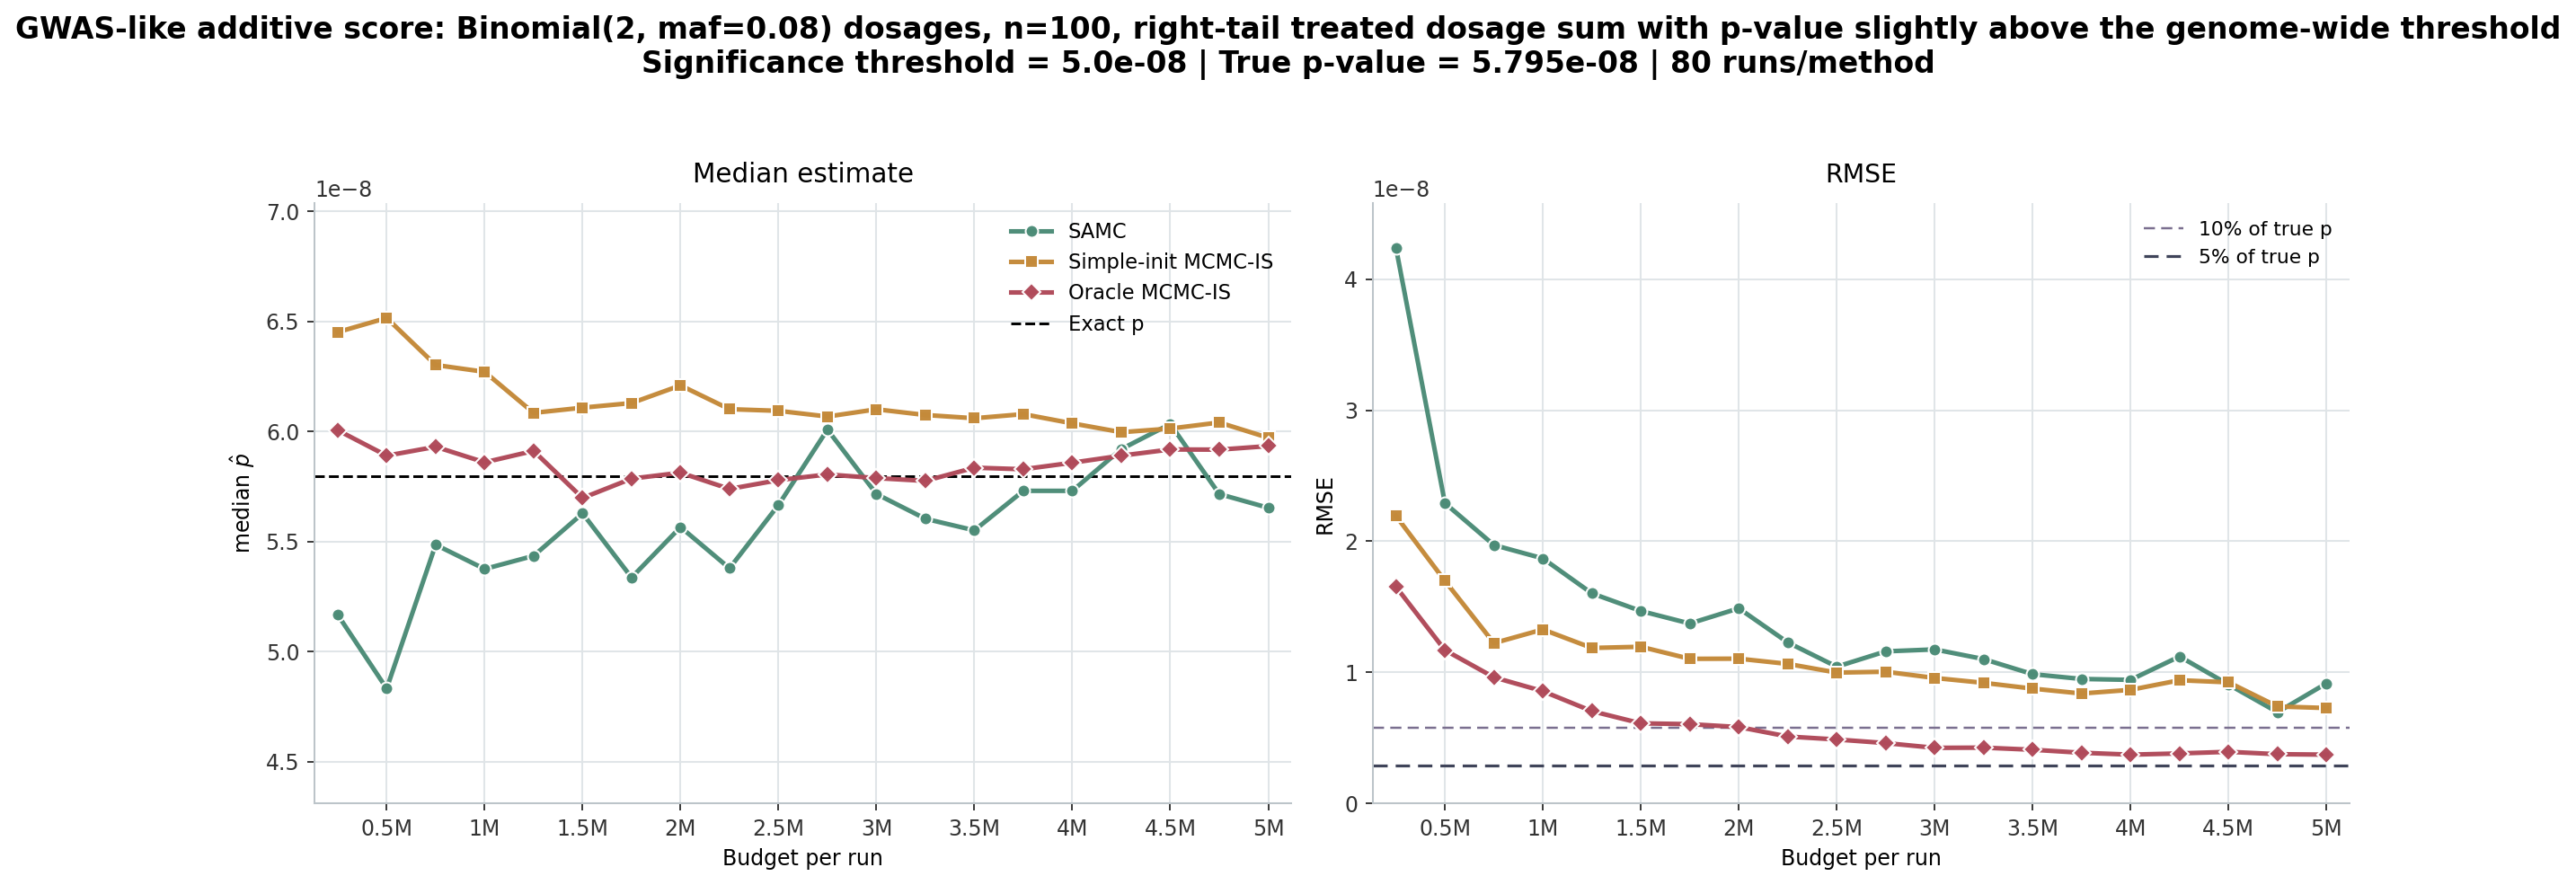


poisson_diffmeans_hep_slight_above_n200


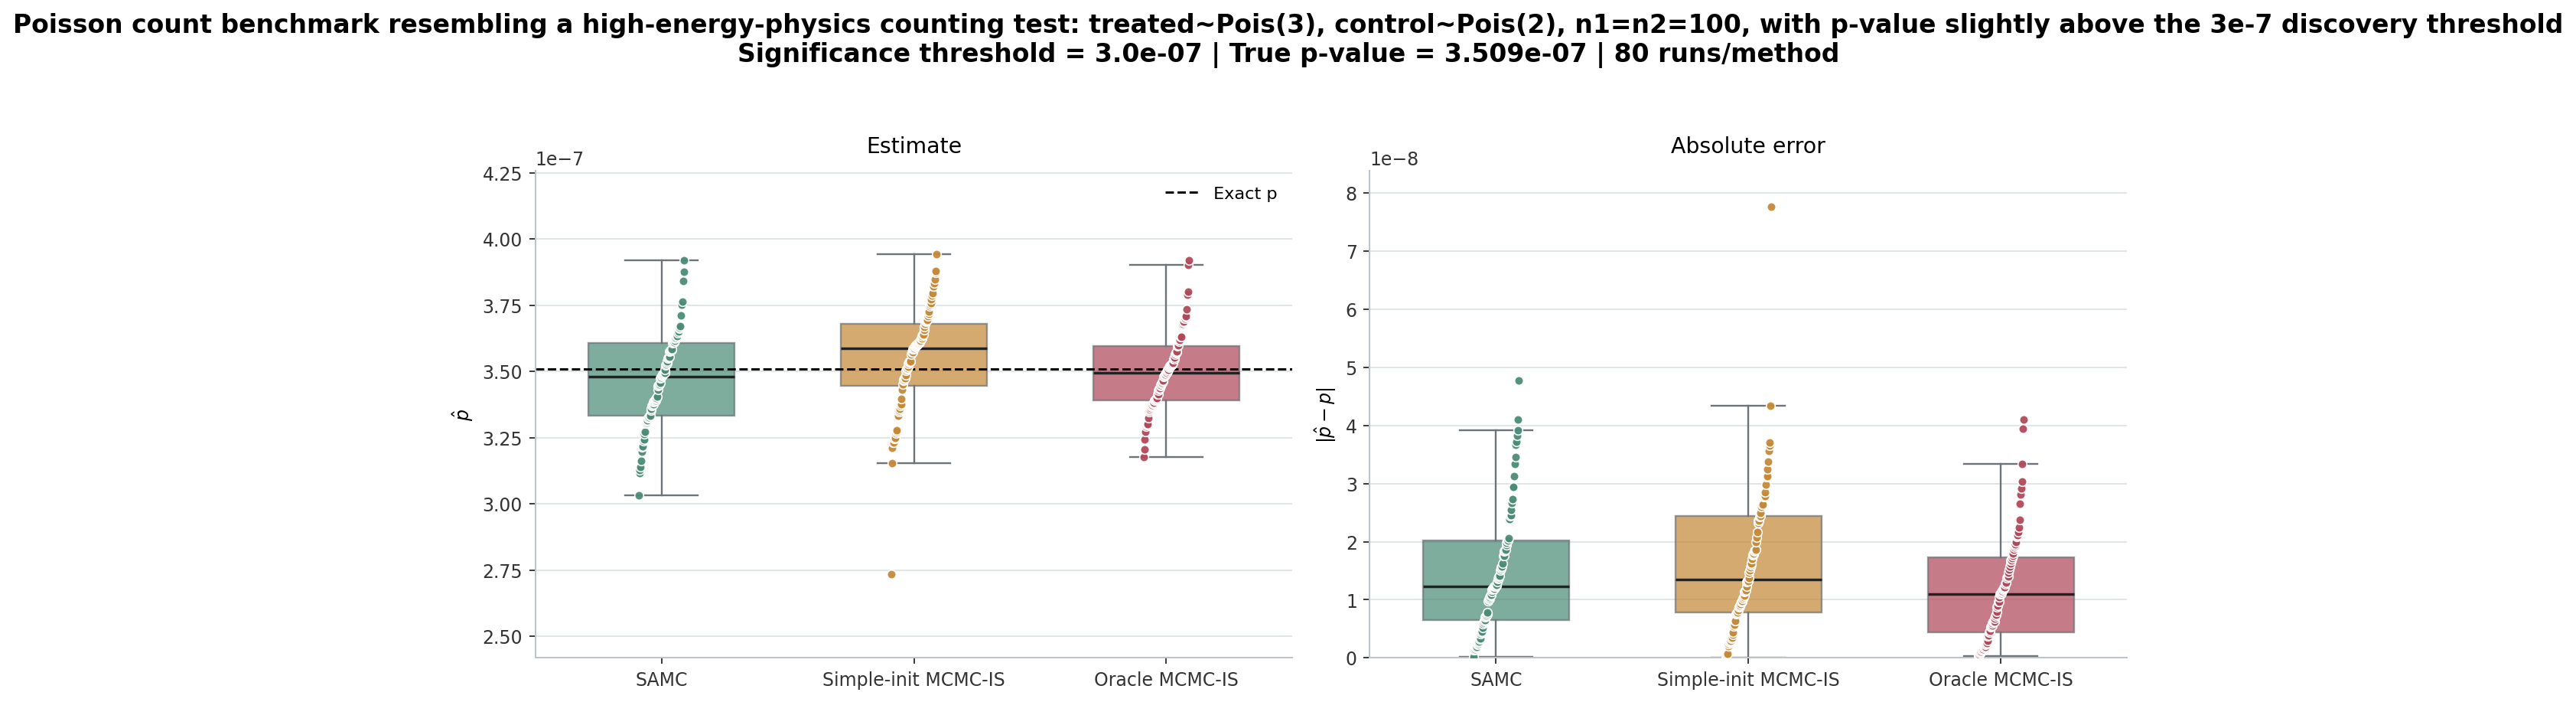

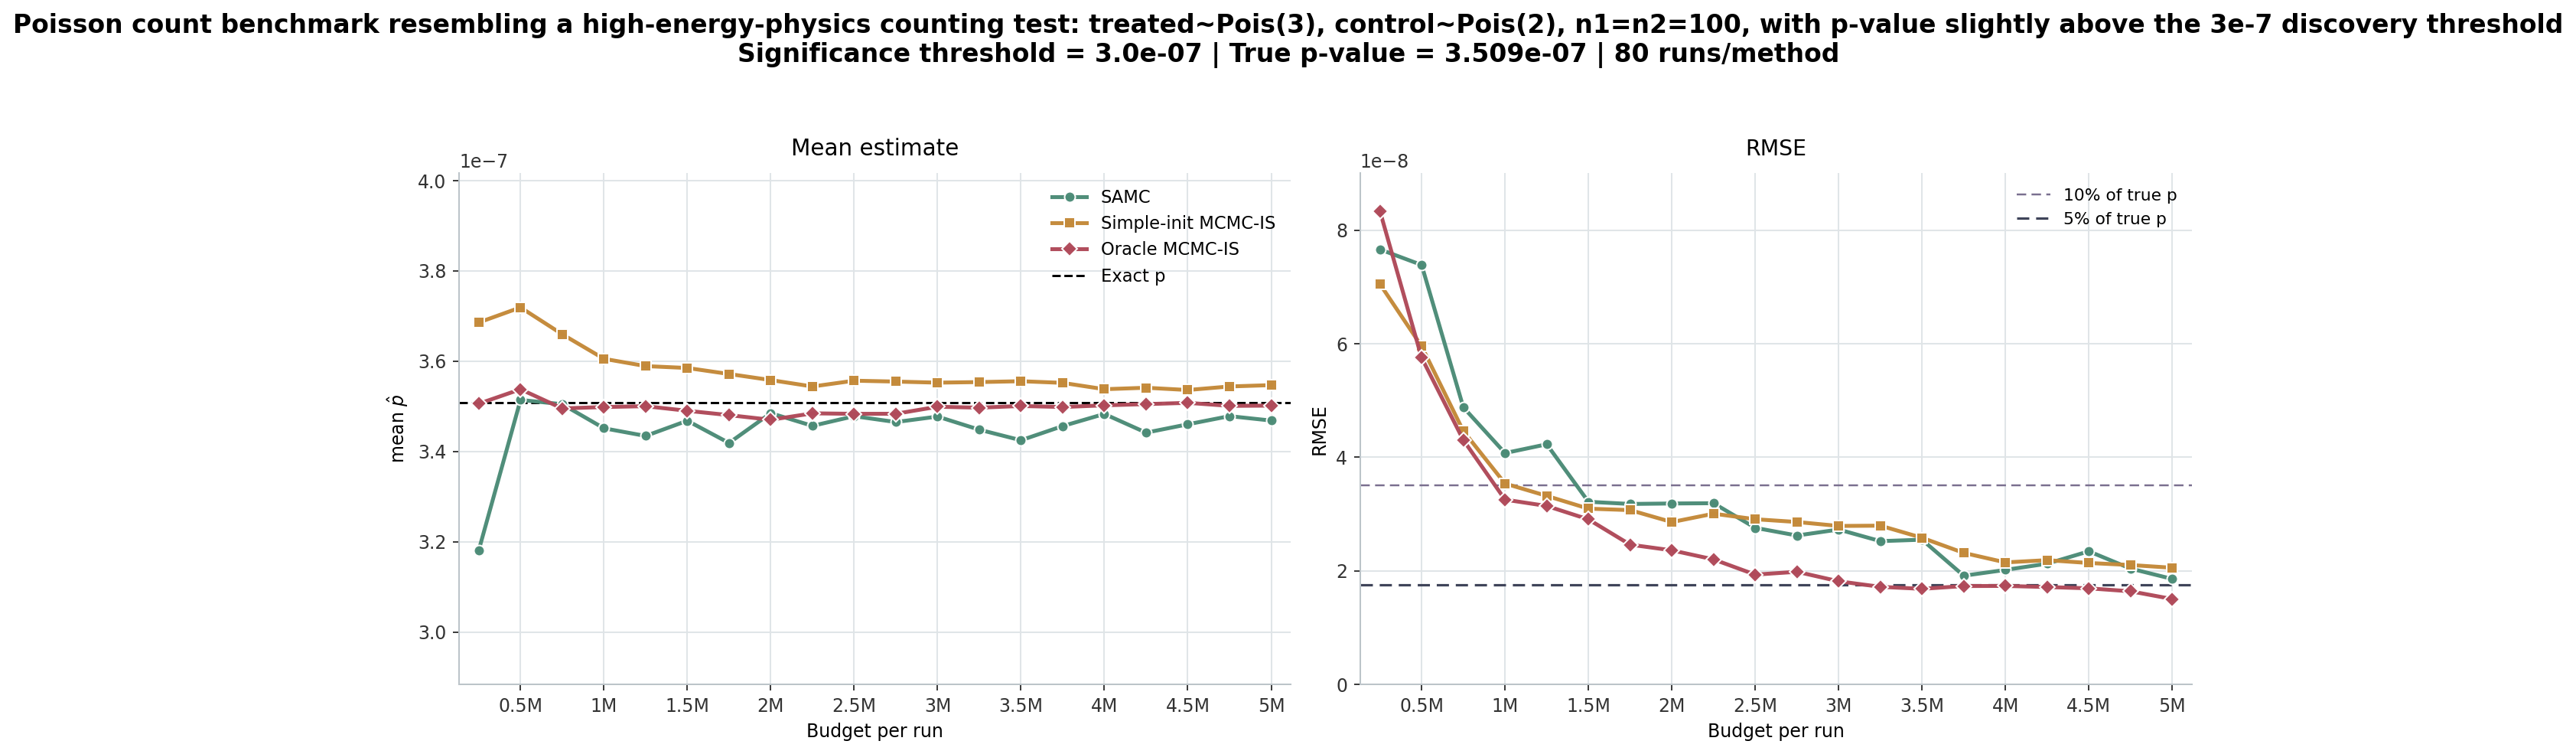

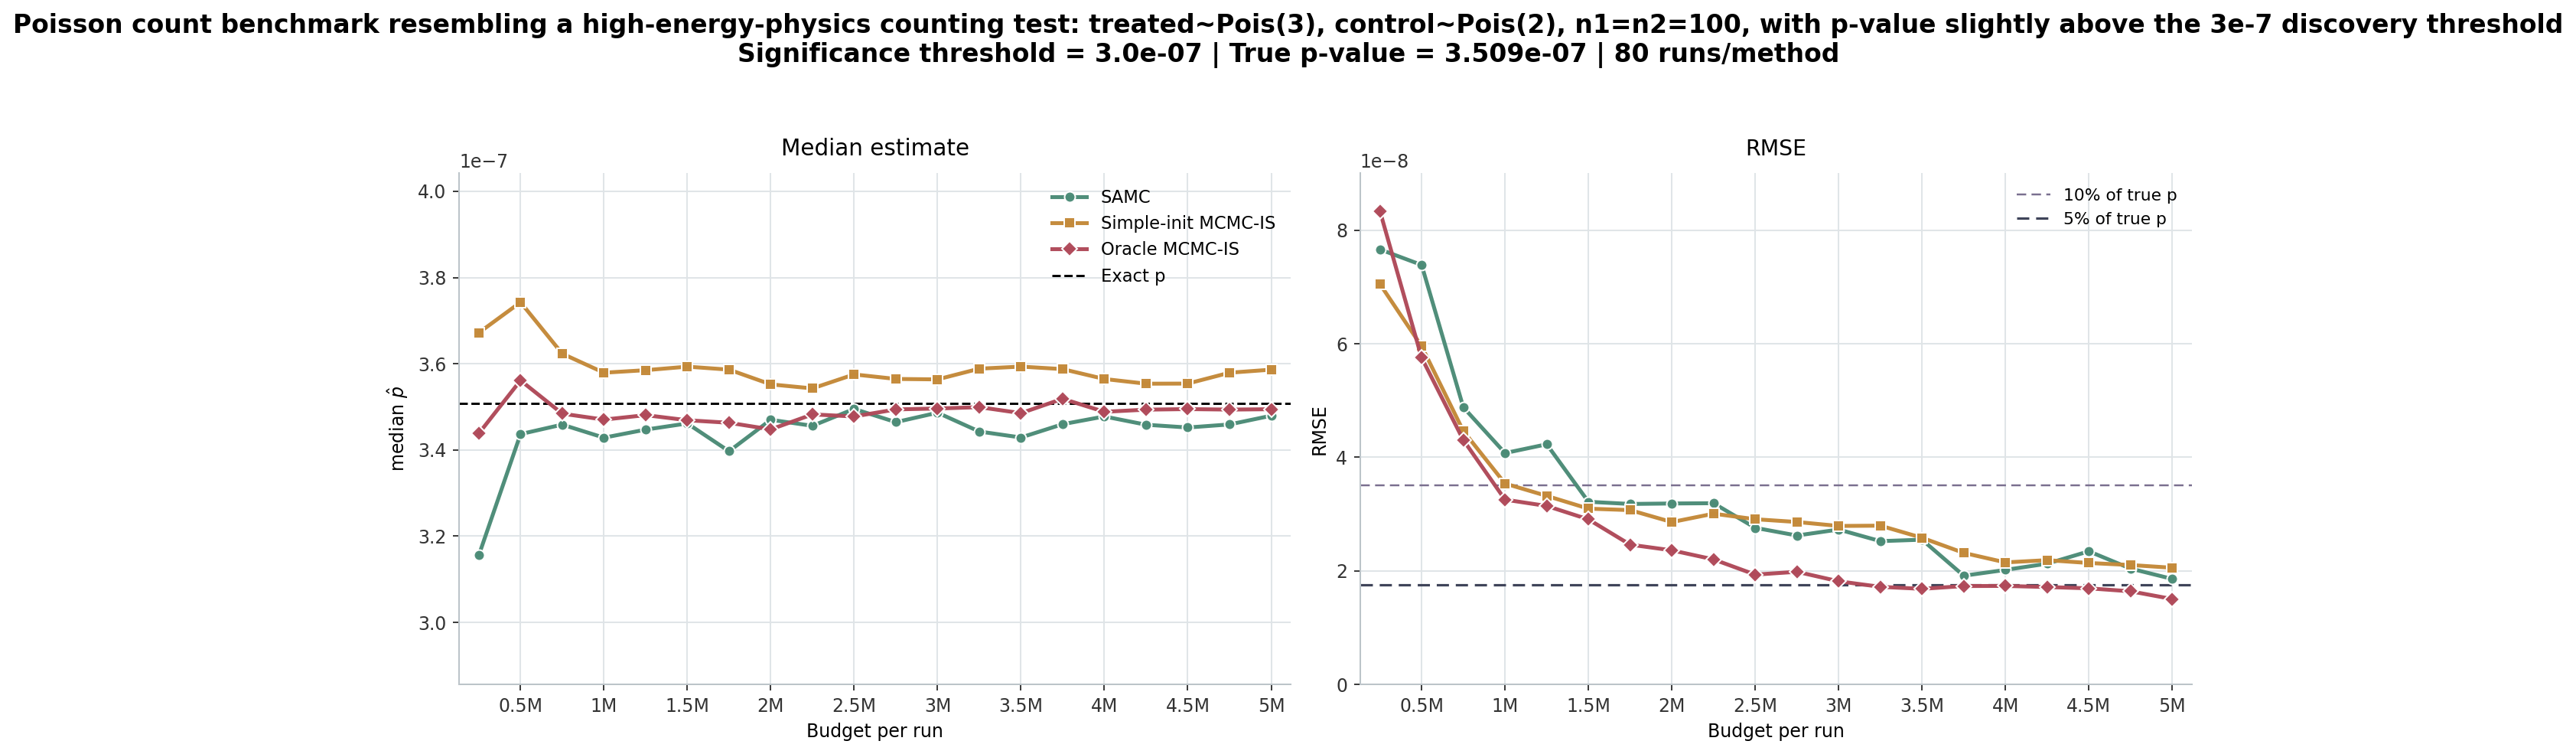

In [6]:
if SAVE_OUTPUTS and run_dir is not None:
    print(f"Saved outputs under: {run_dir}")
    for scenario in scenarios:
        scenario_dir = run_dir / scenario.key
        print(f"\n{scenario.key}")
        display(Image(filename=str(scenario_dir / "cross_method_max_budget.png")))
        display(Image(filename=str(scenario_dir / "cross_method_convergence.png")))
        display(Image(filename=str(scenario_dir / "cross_method_convergence_median.png")))
else:
    print("SAVE_OUTPUTS=False, so no saved figures to display.")

## Reload Saved Results Without Rerunning

In [7]:
# RELOAD_SCENARIO_DIR = None
# # Example:
# # RELOAD_SCENARIO_DIR = project_root / "results" / "cross_method_notebook" / "20260617_120000_cross_method_oracle_beta_slight_above_compare" / "gwas_additive_score_slight_above_n100"

# if RELOAD_SCENARIO_DIR is not None:
#     saved = load_cross_method_saved_output(RELOAD_SCENARIO_DIR)
#     print(json.dumps({
#         "scenario": saved["metadata"]["scenario"],
#         "exact_p": saved["metadata"]["exact_p"],
#         "methods": saved["metadata"]["method_order"],
#     }, indent=2))
#     regen = regenerate_oracle_cross_method_plots(RELOAD_SCENARIO_DIR)
#     for name, path in regen.items():
#         print(name, path)
#         display(Image(filename=str(path)))
# else:
#     print("Set RELOAD_SCENARIO_DIR to a saved scenario directory to regenerate the three article-facing plots.")